In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8")

In [16]:
# Step-1 Generate a Dummy Dataset
X, y = make_blobs(n_samples=2000, n_features=2, cluster_std=3,centers=2,random_state=42)
n_features = 2
print(X.shape, y.shape)

(2000, 2) (2000,)


In [6]:
# Step - 2 Visualize Dataset
def visualize(X,y):
  plt.scatter(X[:,0], X[:,1],c=y,cmap="viridis")
  plt.show()

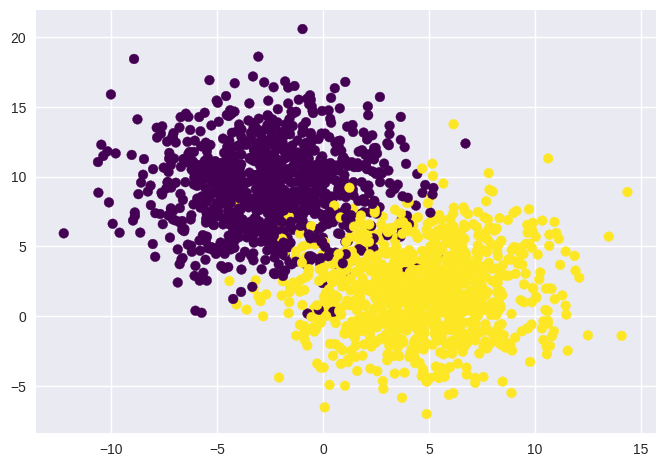

In [7]:
visualize(X,y)

In [8]:
# Step 3 Normalization
def normalise(X):
  u = X.mean(axis=0)
  std = X.std(axis=0)

  return (X-u)/std

In [9]:
X = normalise(X)

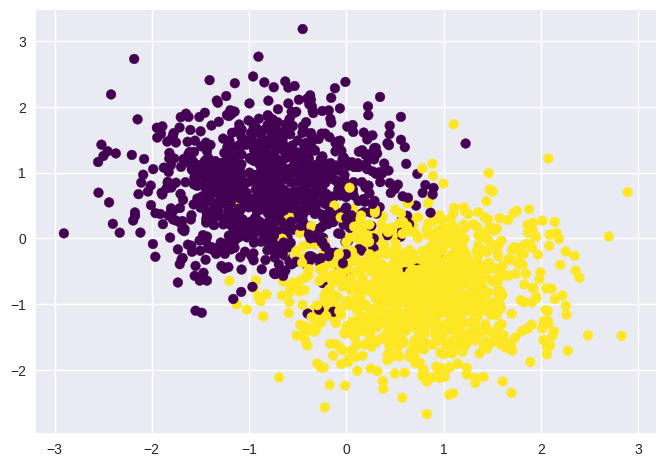

In [10]:
visualize(X,y)

In [11]:
# Step-4 Train Test Split
XT, Xt, yT, yt = train_test_split(X,y, test_size=0.25, shuffle=False, random_state=0)

print(XT.shape, yT.shape)
print(Xt.shape, yt.shape)

(1500, 2) (1500,)
(500, 2) (500,)


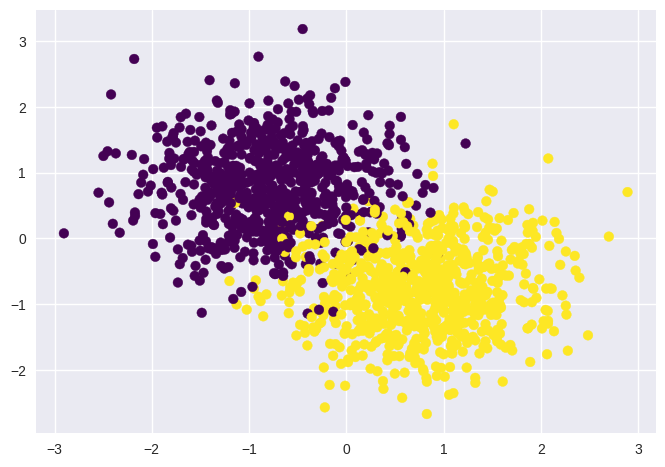

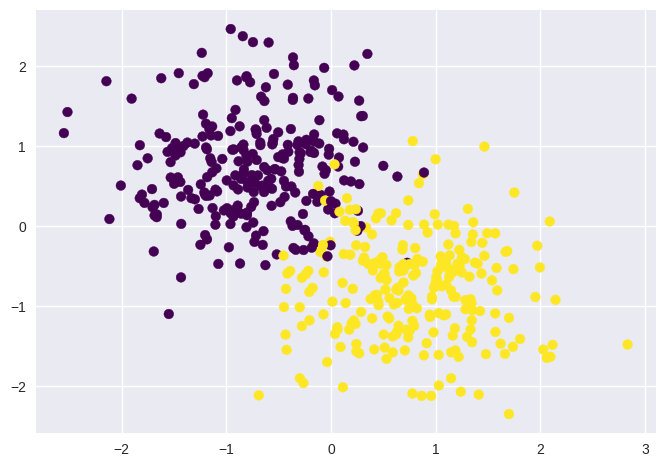

In [12]:
visualize(XT,yT)
visualize(Xt, yt)

In [39]:
# Step 5 Model
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def hypothesis(X,theta):
  return sigmoid(np.dot(X,theta))

# Binary Cross Entropy
def error(y,yp):
  loss = -np.mean(y*np.log(yp) + (1-y)*np.log(1-yp))
  return loss

# Gradient Descent
def gradient(X,y,yp):
  m = X.shape[0]
  grad = -(1/m)*np.dot(X.T, (y-yp))
  return grad

def train(X,y,max_iters=100,learning_rate = 0.1):
  # Randomly initialize theta
  theta = np.random.randn(n_features + 1,1)

  error_list = []
  for i in range(max_iters):
    yp = hypothesis(X,theta)
    e = error(y,yp)
    error_list.append(e)
    grad = gradient(X,y,yp)
    theta = theta - learning_rate*grad

  plt.plot(error_list)
  return theta

def predict(X,theta):
  h = hypothesis(X,theta)
  preds = np.zeros((X.shape[0],1),dtype='int')
  preds[h >= 0.5] = 1

  return preds

def accuracy(X,y,theta):
  preds = predict(X,theta)
  return ((y==preds).sum())/y.shape[0]*100

In [22]:
def addExtraColumn(X):
  if X.shape[1] == n_features :
    ones = np.ones((X.shape[0],1))
    X = np.hstack((ones,X))\

  return X

In [17]:
XT = addExtraColumn(XT)
Xt = addExtraColumn(Xt)
print(XT)
print(Xt)

[[ 1.         -1.43211741  0.65078613]
 [ 1.         -0.47100516  0.87372191]
 [ 1.         -0.40182883  2.1275269 ]
 ...
 [ 1.          0.02390726  0.74454457]
 [ 1.         -0.35936993  0.18771848]
 [ 1.          1.09360417 -1.10077065]]
[[ 1.         -1.17860853  1.9119189 ]
 [ 1.          0.70445084 -1.55536144]
 [ 1.          0.39063944 -0.10336496]
 ...
 [ 1.          1.96970601 -0.24632291]
 [ 1.         -0.80805197 -0.01411826]
 [ 1.          0.83964924  0.53655099]]


In [18]:
print(XT.shape)

(1500, 3)


In [19]:
yT = yT.reshape(-1,1)
yt = yt.reshape(-1,1)

In [20]:
print(yT.shape)
print(yT.shape)

(1500, 1)
(1500, 1)


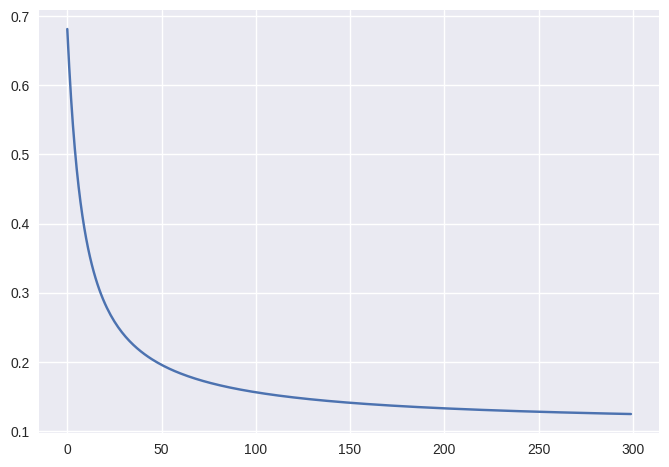

In [28]:
theta = train(XT,yT, max_iters=300,learning_rate= 0.2)

In [29]:
theta

array([[ 0.03688278],
       [ 2.49941712],
       [-2.64023624]])

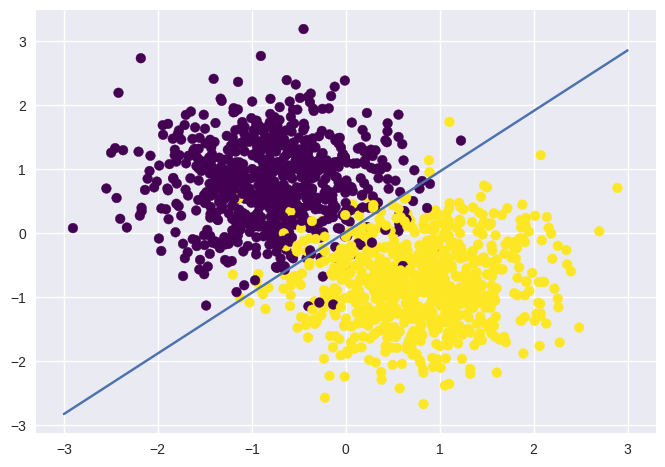

In [30]:
plt.scatter(XT[:,1],XT[:,2],c=yT,cmap="viridis")

x1 = np.linspace(-3,3,6)
x2 = -(theta[0] + theta[1]*x1)/theta[2]
plt.plot(x1,x2)
plt.show()

In [32]:
# Predicitions
preds = predict(Xt,theta)


In [40]:
accuracy(XT,yT,theta)

np.float64(95.86666666666666)

In [42]:
accuracy(Xt,yt,theta)

np.float64(96.39999999999999)

**Implementing Logistic Regression using SkLearn Library**

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
# Create
X,y = make_blobs(n_samples = 2000, n_features=2, cluster_std=3, centers = 2, random_state=42)
model = LogisticRegression()

In [53]:
# Training
model.fit(X,y)

LogisticRegression()

In [54]:
# Predictions
model.predict(X)

array([0, 0, 0, ..., 1, 0, 1])

In [55]:
# Scoring
model.score(X,y)

0.96